# Spicy 1 Transformer Copy Mechanism

This notebook replaces the GRU seq2seq model with a Transformer encoder-decoder and keeps a pointer-generator copy mechanism. The training pipeline is designed to use the full filtered training set by default, while allowing a smaller debug subset through `MAX_TRAIN_SAMPLES`.

---

## 提高性能的 v3 训练方案（`transformer_copy_v3`）

**目标**：在不大改数据管线的前提下，提升 BLEU/METEOR/BERTScore 与生成可读性（减少重复 copy、空话）。

| 方向 | v2（基线） | v3（本方案） |
|------|------------|--------------|
| 结构 | enc/dec 各 3 层 | **各 4 层**（更强表征，checkpoint 仍由 `model_config` 驱动推理） |
| 训练损失 | 仅 NLL + label smoothing | NLL + smoothing + **Coverage 损失**（See et al.，惩罚对同一源位置的重复注意力） |
| 正则 | dropout 0.15, wd 1e-4 | dropout **0.12**, AdamW **wd=0.01** |
| 平滑 | 0.05 | **0.08**（略抑过拟合高频套话） |
| 学习率 | 3e-4, OneCycle pct_start=0.08 | **2.5e-4**, pct_start=**0.10**（更稳 warmup） |
| 轮次与早停 | 20 / patience 3 | **25** / patience **4** |
| 验证集 loss | 纯 NLL | **仍为纯 NLL**（与 v2 dev 曲线可比）；coverage **仅参与训练** |

**操作建议**：先完整跑 v3，将 `best_transformer_copy_v3.pt` 与 `training_runs/transformer_copy_v3/` 下日志、test 指标与 v2 对比；部署时把 `RECIPE_CHECKPOINT` 指向新权重并在固定 prompt 上做人工抽查。


In [1]:
import os
from pathlib import Path
from datetime import datetime
import csv
import json
import ast
import math
import random
import time
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.tokenize import word_tokenize

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(device)
print(f'seed={SEED}')


cuda
seed=42


In [2]:
data_dir = Path.cwd() / 'Cooking_Dataset'
if data_dir.exists():
    os.chdir(data_dir)
print(Path.cwd())


g:\FIT5120\FIT5120-ClimateQuest\AI Development\Cooking_Dataset


In [3]:
import nltk

nltk.download("punkt_tab")
nltk.download("punkt")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Tarami\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Tarami\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

SPECIAL_TOKENS = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']

MAX_INPUT_LEN = 80
MAX_OUTPUT_LEN = 160
MIN_FREQ_INPUT = 1
MIN_FREQ_OUTPUT = 1

# Full filtered training set by default. Set to an integer such as 50000 for quick experiments.
MAX_TRAIN_SAMPLES = None
DEV_SAMPLE_SIZE = None

BATCH_SIZE = 32
NUM_WORKERS = 0


In [5]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {tok: i for i, tok in enumerate(SPECIAL_TOKENS)}
        self.index2word = {i: tok for i, tok in enumerate(SPECIAL_TOKENS)}
        self.word2count = Counter()
        self.n_words = len(SPECIAL_TOKENS)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.n_words += 1

    def build_from_counter(self, counter, min_freq=1, max_vocab=None):
        kept = 0
        for word, count in counter.most_common():
            if count < min_freq:
                continue
            if max_vocab is not None and kept >= max_vocab:
                break
            self.addWord(word)
            self.word2count[word] = count
            kept += 1


def normalizeRecipeString(s):
    return str(s).lower().strip()


def tokenize_text(text):
    return word_tokenize(normalizeRecipeString(text))


In [6]:
def readRecipePairs(csv_path):
    pairs = []
    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                ing_list = ast.literal_eval(row['Ingredients'])
                recipe_steps = ast.literal_eval(row['Recipe'])
                ing_text = ', '.join(str(x) for x in ing_list)
                recipe_text = ' '.join(str(x) for x in recipe_steps).strip()
                pairs.append((ing_text, recipe_text))
            except Exception as exc:
                print('Skip one data row:', exc, row)
    return pairs


def filter_pair(pair):
    input_len = len(tokenize_text(pair[0]))
    output_len = len(tokenize_text(pair[1]))
    return 0 < input_len <= MAX_INPUT_LEN and 0 < output_len <= MAX_OUTPUT_LEN


def filterPairs(pairs):
    return [p for p in pairs if filter_pair(p)]


def maybe_sample_pairs(pairs, max_samples=None):
    if max_samples is None or len(pairs) <= max_samples:
        return pairs
    rng = random.Random(SEED)
    return rng.sample(pairs, max_samples)


def buildLangsFromPairs(train_pairs):
    input_counter = Counter()
    output_counter = Counter()
    for ing, recipe in train_pairs:
        input_counter.update(tokenize_text(ing))
        output_counter.update(tokenize_text(recipe))

    input_lang = Lang('ingredients')
    output_lang = Lang('recipes')
    input_lang.build_from_counter(input_counter, min_freq=MIN_FREQ_INPUT)
    output_lang.build_from_counter(output_counter, min_freq=MIN_FREQ_OUTPUT)
    return input_lang, output_lang


def prepareRecipeData(train_csv='train.csv', dev_csv='dev.csv', test_csv='test.csv'):
    train_pairs = maybe_sample_pairs(filterPairs(readRecipePairs(train_csv)), MAX_TRAIN_SAMPLES)
    dev_pairs = filterPairs(readRecipePairs(dev_csv)) if Path(dev_csv).exists() else []
    test_pairs = filterPairs(readRecipePairs(test_csv)) if Path(test_csv).exists() else []
    dev_pairs = maybe_sample_pairs(dev_pairs, DEV_SAMPLE_SIZE)

    input_lang, output_lang = buildLangsFromPairs(train_pairs)
    print(f'Train samples: {len(train_pairs):,}')
    print(f'Dev samples: {len(dev_pairs):,}')
    print(f'Test samples: {len(test_pairs):,}')
    print(f'Input vocabulary: {input_lang.n_words:,}')
    print(f'Output vocabulary: {output_lang.n_words:,}')
    return input_lang, output_lang, train_pairs, dev_pairs, test_pairs

input_lang, output_lang, train_pairs, dev_pairs, test_pairs = prepareRecipeData()
print(random.choice(train_pairs))


Train samples: 155,248
Dev samples: 1,005
Test samples: 1,043
Input vocabulary: 10,757
Output vocabulary: 15,558
('3 oz. cream cheese, softened, 1 small can crabmeat, seafood cocktail sauce', 'Rinse and drain the crabmeat. Blend cream cheese, crabmeat and cocktail sauce. Chill. Serve with crackers.')


In [7]:
def source_ids(tokens, input_lang):
    return [input_lang.word2index.get(tok, UNK_token) for tok in tokens] + [EOS_token]


def target_input_ids(tokens, output_lang):
    return [SOS_token] + [output_lang.word2index.get(tok, UNK_token) for tok in tokens]


def source_copy_ids(tokens, output_lang):
    """Map source positions into the decoder/extended vocabulary space."""
    oov_list = []
    ids = []
    for tok in tokens:
        if tok in output_lang.word2index:
            ids.append(output_lang.word2index[tok])
        else:
            if tok not in oov_list:
                oov_list.append(tok)
            ids.append(output_lang.n_words + oov_list.index(tok))
    ids.append(EOS_token)
    return ids, oov_list


def target_extended_ids(tokens, output_lang, oov_list):
    ids = []
    for tok in tokens:
        if tok in output_lang.word2index:
            ids.append(output_lang.word2index[tok])
        elif tok in oov_list:
            ids.append(output_lang.n_words + oov_list.index(tok))
        else:
            ids.append(UNK_token)
    ids.append(EOS_token)
    return ids


class RecipeCopyDataset(Dataset):
    def __init__(self, pairs, input_lang, output_lang):
        self.examples = []
        for ing, recipe in pairs:
            src_tokens = tokenize_text(ing)
            tgt_tokens = tokenize_text(recipe)
            src = source_ids(src_tokens, input_lang)
            src_copy, oov = source_copy_ids(src_tokens, output_lang)
            tgt_in = target_input_ids(tgt_tokens, output_lang)
            tgt_out = target_extended_ids(tgt_tokens, output_lang, oov)
            self.examples.append({
                'src': src,
                'src_copy': src_copy,
                'tgt_in': tgt_in,
                'tgt_out': tgt_out,
                'oov': oov,
                'ingredients': ing,
                'recipe': recipe,
            })

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]


def pad_2d(seqs, pad_value=PAD_token):
    max_len = max(len(s) for s in seqs)
    out = torch.full((len(seqs), max_len), pad_value, dtype=torch.long)
    for i, seq in enumerate(seqs):
        out[i, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    return out


def collate_recipe_batch(batch):
    src = pad_2d([x['src'] for x in batch])
    src_copy = pad_2d([x['src_copy'] for x in batch])
    tgt_in = pad_2d([x['tgt_in'] for x in batch])
    tgt_out = pad_2d([x['tgt_out'] for x in batch])
    max_oov = max(len(x['oov']) for x in batch)
    return {
        'src': src,
        'src_copy': src_copy,
        'tgt_in': tgt_in,
        'tgt_out': tgt_out,
        'extended_vocab_size': output_lang.n_words + max_oov,
        'oov': [x['oov'] for x in batch],
        'ingredients': [x['ingredients'] for x in batch],
        'recipe': [x['recipe'] for x in batch],
    }

train_dataset = RecipeCopyDataset(train_pairs, input_lang, output_lang)
dev_dataset = RecipeCopyDataset(dev_pairs, input_lang, output_lang) if dev_pairs else None
test_dataset = RecipeCopyDataset(test_pairs, input_lang, output_lang) if test_pairs else None

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_recipe_batch, num_workers=NUM_WORKERS)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_recipe_batch, num_workers=NUM_WORKERS) if dev_dataset else None
print(f'Train batches: {len(train_loader):,}')


Train batches: 4,852


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class CopyTransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None, memory_key_padding_mask=None):
        self_out, _ = self.self_attn(
            tgt, tgt, tgt,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False,
        )
        tgt = self.norm1(tgt + self.dropout1(self_out))
        cross_out, cross_weights = self.cross_attn(
            tgt, memory, memory,
            key_padding_mask=memory_key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        tgt = self.norm2(tgt + self.dropout2(cross_out))
        ff = self.linear2(self.dropout(F.gelu(self.linear1(tgt))))
        tgt = self.norm3(tgt + self.dropout3(ff))
        return tgt, cross_weights


class TransformerPointerGenerator(nn.Module):
    def __init__(self, input_vocab_size, output_vocab_size, d_model=256, nhead=8, num_encoder_layers=3,
                 num_decoder_layers=3, dim_feedforward=1024, dropout=0.1):
        super().__init__()
        self.output_vocab_size = output_vocab_size
        self.d_model = d_model
        self.src_embedding = nn.Embedding(input_vocab_size, d_model, padding_idx=PAD_token)
        self.tgt_embedding = nn.Embedding(output_vocab_size, d_model, padding_idx=PAD_token)
        self.positional = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers, enable_nested_tensor=False)
        self.decoder_layers = nn.ModuleList([
            CopyTransformerDecoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_decoder_layers)
        ])
        self.vocab_proj = nn.Linear(d_model, output_vocab_size)
        self.p_gen_proj = nn.Linear(d_model * 3, 1)

    def forward(self, src, tgt_in, src_copy_ids, extended_vocab_size):
        src_padding = src.eq(PAD_token)
        tgt_padding = tgt_in.eq(PAD_token)
        tgt_mask = torch.triu(
            torch.ones(tgt_in.size(1), tgt_in.size(1), dtype=torch.bool, device=tgt_in.device),
            diagonal=1,
        )

        src_emb = self.positional(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional(self.tgt_embedding(tgt_in) * math.sqrt(self.d_model))
        memory = self.encoder(src_emb, src_key_padding_mask=src_padding)

        dec = tgt_emb
        cross_weights = None
        for layer in self.decoder_layers:
            dec, cross_weights = layer(
                dec,
                memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_padding,
                memory_key_padding_mask=src_padding,
            )

        vocab_dist = F.softmax(self.vocab_proj(dec), dim=-1)
        if extended_vocab_size > self.output_vocab_size:
            extra = torch.zeros(
                vocab_dist.size(0),
                vocab_dist.size(1),
                extended_vocab_size - self.output_vocab_size,
                device=vocab_dist.device,
                dtype=vocab_dist.dtype,
            )
            vocab_dist = torch.cat([vocab_dist, extra], dim=-1)

        attn = cross_weights.mean(dim=1)  # [batch, tgt_len, src_len]
        attn = attn.masked_fill(src_padding.unsqueeze(1), 0.0)
        attn = attn / attn.sum(dim=-1, keepdim=True).clamp_min(1e-12)
        context = torch.bmm(attn, memory)

        p_gen = torch.sigmoid(self.p_gen_proj(torch.cat([dec, context, tgt_emb], dim=-1)))
        copy_dist = torch.zeros_like(vocab_dist)
        scatter_index = src_copy_ids.unsqueeze(1).expand(-1, tgt_in.size(1), -1)
        copy_dist.scatter_add_(dim=-1, index=scatter_index, src=attn)
        final_dist = p_gen * vocab_dist + (1 - p_gen) * copy_dist
        return final_dist.clamp_min(1e-12), p_gen, attn


In [9]:
def masked_nll_loss(final_dist, target_ext_ids, label_smoothing=0.0):
    gold_probs = final_dist.gather(dim=-1, index=target_ext_ids.unsqueeze(-1)).squeeze(-1)
    mask = target_ext_ids.ne(PAD_token)
    nll = -torch.log(gold_probs.clamp_min(1e-12))

    if label_smoothing and label_smoothing > 0:
        smooth_loss = -torch.log(final_dist.clamp_min(1e-12)).mean(dim=-1)
        loss = (1.0 - label_smoothing) * nll + label_smoothing * smooth_loss
    else:
        loss = nll

    return loss.masked_select(mask).mean()


def coverage_loss(attn, target_ext_ids, pad_idx=PAD_token):
    """See et al. (2017) coverage auxiliary loss on cross-attention (reduces repeated copy / attention)."""
    cum = torch.cumsum(attn, dim=1)
    prev = cum - attn
    step = torch.minimum(attn, prev.clamp(min=0.0))
    per_step = step.sum(dim=-1)
    mask = target_ext_ids.ne(pad_idx)
    sel = per_step.masked_select(mask)
    if sel.numel() == 0:
        return torch.tensor(0.0, device=target_ext_ids.device, dtype=attn.dtype)
    return sel.mean()


def move_batch_to_device(batch):
    out = dict(batch)
    for key in ['src', 'src_copy', 'tgt_in', 'tgt_out']:
        out[key] = batch[key].to(device)
    return out


def train_one_epoch(model, loader, optimizer, scheduler=None, grad_clip=1.0, print_every=100,
                    label_smoothing=0.0, coverage_weight=0.0):
    model.train()
    total_loss = 0.0
    start = time.time()
    for step, raw_batch in enumerate(loader, 1):
        batch = move_batch_to_device(raw_batch)
        optimizer.zero_grad(set_to_none=True)
        final_dist, _, attn = model(batch['src'], batch['tgt_in'], batch['src_copy'], batch['extended_vocab_size'])
        loss = masked_nll_loss(final_dist, batch['tgt_out'], label_smoothing=label_smoothing)
        if coverage_weight and coverage_weight > 0:
            loss = loss + coverage_weight * coverage_loss(attn, batch['tgt_out'])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
        if step % print_every == 0:
            elapsed = time.time() - start
            print(f'step {step:>5}/{len(loader):<5} loss={total_loss/step:.4f} elapsed={elapsed/60:.1f}m')
    return total_loss / max(1, len(loader))


@torch.no_grad()
def evaluate_loss(model, loader, label_smoothing=0.0):
    """Teacher-forcing NLL only (no coverage term) so dev_loss stays comparable across runs."""
    if loader is None:
        return None
    model.eval()
    total_loss = 0.0
    for raw_batch in loader:
        batch = move_batch_to_device(raw_batch)
        final_dist, _, _ = model(batch['src'], batch['tgt_in'], batch['src_copy'], batch['extended_vocab_size'])
        total_loss += masked_nll_loss(final_dist, batch['tgt_out'], label_smoothing=label_smoothing).item()
    return total_loss / max(1, len(loader))

In [10]:
RUN_NAME = 'transformer_copy_v3'
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'Cooking_Dataset' else Path.cwd()
CHECKPOINT_PATH = f'best_{RUN_NAME}.pt'
TRAINING_RUN_DIR = PROJECT_DIR / 'training_runs' / RUN_NAME
TRAINING_RUN_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CONFIG = {
    'd_model': 256,
    'nhead': 8,
    'num_encoder_layers': 4,
    'num_decoder_layers': 4,
    'dim_feedforward': 1024,
    'dropout': 0.12,
}

TRAINING_CONFIG = {
    'epochs': 25,
    'learning_rate': 2.5e-4,
    'weight_decay': 0.01,
    'label_smoothing': 0.08,
    'coverage_loss_weight': 0.5,
    'early_stopping_patience': 4,
    'grad_clip': 1.0,
    'print_every': 100,
}


def build_model():
    return TransformerPointerGenerator(
        input_vocab_size=input_lang.n_words,
        output_vocab_size=output_lang.n_words,
        **MODEL_CONFIG,
    ).to(device)


model = build_model()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=TRAINING_CONFIG['learning_rate'],
    weight_decay=TRAINING_CONFIG['weight_decay'],
)
total_steps = max(1, TRAINING_CONFIG['epochs'] * len(train_loader))
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=TRAINING_CONFIG['learning_rate'],
    total_steps=total_steps,
    pct_start=0.10,
    anneal_strategy='cos',
)


def export_lang_state(lang):
    return {
        'name': lang.name,
        'word2index': lang.word2index,
        'index2word': lang.index2word,
        'word2count': dict(lang.word2count),
        'n_words': lang.n_words,
    }


def restore_lang_state(state):
    lang = Lang(state['name'])
    lang.word2index = {str(k): int(v) for k, v in state['word2index'].items()}
    lang.index2word = {int(k): str(v) for k, v in state['index2word'].items()}
    lang.word2count = Counter(state.get('word2count', {}))
    lang.n_words = int(state['n_words'])
    return lang


def save_checkpoint(path, model, input_lang, output_lang, best_dev_loss, epoch, train_losses, dev_losses):
    torch.save({
        'model_state_dict': model.state_dict(),
        'input_lang': export_lang_state(input_lang),
        'output_lang': export_lang_state(output_lang),
        'best_dev_loss': best_dev_loss,
        'epoch': epoch,
        'model_config': MODEL_CONFIG,
        'training_config': TRAINING_CONFIG,
        'train_losses': train_losses,
        'dev_losses': dev_losses,
    }, path)


def load_checkpoint(path, model=None, map_location=device):
    checkpoint = torch.load(path, map_location=map_location, weights_only=False)
    if model is None:
        model = build_model()
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    return model, checkpoint


def save_training_log(path, train_losses, dev_losses, best_dev_loss, best_epoch):
    rows = []
    for idx, train_loss in enumerate(train_losses, 1):
        rows.append({
            'epoch': idx,
            'train_loss': train_loss,
            'dev_loss': dev_losses[idx - 1] if idx - 1 < len(dev_losses) else None,
        })
    payload = {
        'run_name': RUN_NAME,
        'created_at': datetime.now().isoformat(timespec='seconds'),
        'device': str(device),
        'checkpoint_path': CHECKPOINT_PATH,
        'model_config': MODEL_CONFIG,
        'training_config': TRAINING_CONFIG,
        'best_epoch': best_epoch,
        'best_dev_loss': best_dev_loss,
        'history': rows,
    }
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(payload, f, indent=2)


best_dev_loss = float('inf')
best_epoch = None
train_losses = []
dev_losses = []
patience_counter = 0

for epoch in range(1, TRAINING_CONFIG['epochs'] + 1):
    print(f'\nEpoch {epoch}/{TRAINING_CONFIG["epochs"]}')
    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler=scheduler,
        grad_clip=TRAINING_CONFIG['grad_clip'],
        print_every=TRAINING_CONFIG['print_every'],
        label_smoothing=TRAINING_CONFIG['label_smoothing'],
        coverage_weight=TRAINING_CONFIG['coverage_loss_weight'],
    )
    dev_loss = evaluate_loss(model, dev_loader, label_smoothing=0.0)
    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    print(f'epoch={epoch} train_loss={train_loss:.4f} dev_loss={dev_loss if dev_loss is not None else float("nan"):.4f}')

    improved = dev_loss is not None and dev_loss < best_dev_loss - 1e-4
    if improved:
        best_dev_loss = dev_loss
        best_epoch = epoch
        patience_counter = 0
        save_checkpoint(CHECKPOINT_PATH, model, input_lang, output_lang, best_dev_loss, epoch, train_losses, dev_losses)
        print(f'Saved best checkpoint to {CHECKPOINT_PATH}')
    else:
        patience_counter += 1
        print(f'No dev improvement. patience={patience_counter}/{TRAINING_CONFIG["early_stopping_patience"]}')

    save_training_log(TRAINING_RUN_DIR / 'training_log.json', train_losses, dev_losses, best_dev_loss, best_epoch)

    if patience_counter >= TRAINING_CONFIG['early_stopping_patience']:
        print('Early stopping triggered.')
        break

# Always reload the best checkpoint before generation/evaluation.
if Path(CHECKPOINT_PATH).exists():
    model, best_checkpoint = load_checkpoint(CHECKPOINT_PATH)
    print(f'Loaded best checkpoint from epoch {best_checkpoint["epoch"]} with dev_loss={best_checkpoint["best_dev_loss"]:.4f}')
else:
    print(f'Warning: checkpoint not found at {CHECKPOINT_PATH}. Evaluation will use the current in-memory model.')


Epoch 1/20
step   100/4852  loss=9.8983 elapsed=0.7m
step   200/4852  loss=9.1001 elapsed=1.2m
step   300/4852  loss=8.5546 elapsed=1.8m
step   400/4852  loss=8.1259 elapsed=2.3m
step   500/4852  loss=7.7784 elapsed=2.8m
step   600/4852  loss=7.4942 elapsed=3.2m
step   700/4852  loss=7.2557 elapsed=3.8m
step   800/4852  loss=7.0545 elapsed=4.5m
step   900/4852  loss=6.8801 elapsed=4.9m
step  1000/4852  loss=6.7273 elapsed=5.4m
step  1100/4852  loss=6.5910 elapsed=5.9m
step  1200/4852  loss=6.4682 elapsed=6.6m
step  1300/4852  loss=6.3559 elapsed=7.2m
step  1400/4852  loss=6.2516 elapsed=7.9m
step  1500/4852  loss=6.1561 elapsed=8.5m
step  1600/4852  loss=6.0670 elapsed=9.1m
step  1700/4852  loss=5.9837 elapsed=9.8m
step  1800/4852  loss=5.9067 elapsed=10.3m
step  1900/4852  loss=5.8322 elapsed=10.8m
step  2000/4852  loss=5.7647 elapsed=11.4m
step  2100/4852  loss=5.6993 elapsed=12.0m
step  2200/4852  loss=5.6380 elapsed=12.4m
step  2300/4852  loss=5.5797 elapsed=13.3m
step  2400/4852 

C:\Users\Tarami\AppData\Local\Temp\ipykernel_11880\6165891.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=map_location)


In [11]:
def decode_token(token_id, output_lang, oov_list):
    if token_id < output_lang.n_words:
        return output_lang.index2word.get(token_id, '<UNK>')
    idx = token_id - output_lang.n_words
    if 0 <= idx < len(oov_list):
        return oov_list[idx]
    return '<UNK>'


def ids_to_words(token_ids, output_lang, oov_list):
    words = []
    for token_id in token_ids:
        if token_id in {PAD_token, SOS_token, EOS_token}:
            continue
        word = decode_token(token_id, output_lang, oov_list)
        if word not in SPECIAL_TOKENS:
            words.append(word)
    return words


def normalize_generated_text(text):
    words = text.split()
    cleaned = []
    for word in words:
        if len(cleaned) >= 2 and cleaned[-1] == word and cleaned[-2] == word:
            continue
        cleaned.append(word)
    text = ' '.join(cleaned)
    text = text.replace(' .', '.').replace(' ,', ',').replace(' ;', ';').replace(' :', ':')
    return text.strip()


def sentence_split(text):
    pieces = []
    for part in text.replace('!', '.').replace('?', '.').split('.'):
        part = part.strip(' ,;')
        if part:
            pieces.append(part)
    return pieces


def format_recipe_steps(text, min_steps=2):
    text = normalize_generated_text(text)
    steps = []
    seen = set()
    for sentence in sentence_split(text):
        key = ' '.join(tokenize_text(sentence))
        if not key or key in seen:
            continue
        seen.add(key)
        sentence = sentence[0].upper() + sentence[1:] if sentence else sentence
        steps.append(sentence.rstrip('.') + '.')
    if len(steps) < min_steps:
        return text
    return '\n'.join(f'{i}. {step}' for i, step in enumerate(steps, 1))



def repetition_rate(text, n=3):
    tokens = tokenize_text(text)
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    if not ngrams:
        return 0.0
    return 1.0 - (len(set(ngrams)) / len(ngrams))


def ingredient_coverage(ingredients, generated):
    ingredient_tokens = set(tokenize_text(ingredients))
    generated_tokens = set(tokenize_text(generated))
    stop_tokens = {',', '.', 'and', 'or', '(', ')', 'c.', 'tbsp.', 'tsp.', 'oz.', 'lb.', 'pkg.', 'can'}
    ingredient_tokens = {tok for tok in ingredient_tokens if tok not in stop_tokens and not tok.replace('/', '').replace('.', '').isdigit()}
    if not ingredient_tokens:
        return 0.0
    return len(ingredient_tokens & generated_tokens) / len(ingredient_tokens)

def has_repeated_ngram(token_ids, candidate_id, n=3):
    if n is None or n <= 0 or len(token_ids) < n - 1:
        return False
    ngrams = set(tuple(token_ids[i:i+n]) for i in range(len(token_ids) - n + 1))
    new_ngram = tuple((token_ids + [candidate_id])[-n:])
    return new_ngram in ngrams


@torch.no_grad()
def generate_recipe_sampling(model, ingredient_text, max_len=MAX_OUTPUT_LEN, min_len=8, temperature=0.9, top_k=10):
    model.eval()
    src_tokens = tokenize_text(ingredient_text)
    src = source_ids(src_tokens, input_lang)
    src_copy, oov_list = source_copy_ids(src_tokens, output_lang)
    src_tensor = torch.tensor([src], dtype=torch.long, device=device)
    src_copy_tensor = torch.tensor([src_copy], dtype=torch.long, device=device)
    generated = [SOS_token]
    words = []
    extended_vocab_size = output_lang.n_words + len(oov_list)

    for _ in range(max_len):
        decoder_input_ids = [tok if tok < output_lang.n_words else UNK_token for tok in generated]
        tgt_in = torch.tensor([decoder_input_ids], dtype=torch.long, device=device)
        final_dist, _, _ = model(src_tensor, tgt_in, src_copy_tensor, extended_vocab_size)
        probs = final_dist[0, -1].clone()
        probs[PAD_token] = 0
        probs[SOS_token] = 0
        if len(words) < min_len:
            probs[EOS_token] = 0
        if words:
            last_id = generated[-1]
            if last_id < probs.numel():
                probs[last_id] *= 0.35
        if top_k and top_k < probs.numel():
            keep = torch.topk(probs, top_k).indices
            masked = torch.zeros_like(probs)
            masked[keep] = probs[keep]
            probs = masked
        probs = torch.pow(probs.clamp_min(1e-12), 1 / max(temperature, 1e-6))
        probs = probs / probs.sum()
        token_id = torch.multinomial(probs, 1).item()
        generated.append(token_id)
        if token_id == EOS_token:
            break
        word = decode_token(token_id, output_lang, oov_list)
        if word not in SPECIAL_TOKENS:
            words.append(word)
    return normalize_generated_text(' '.join(words))


@torch.no_grad()
def generate_recipe_beam_search(model, ingredient_text, max_len=120, min_len=20, beam_size=4,
                                length_penalty=0.8, repetition_penalty=1.2, no_repeat_ngram_size=3,
                                candidate_multiplier=4, format_steps=False):
    model.eval()
    src_tokens = tokenize_text(ingredient_text)
    src = source_ids(src_tokens, input_lang)
    src_copy, oov_list = source_copy_ids(src_tokens, output_lang)
    src_tensor = torch.tensor([src], dtype=torch.long, device=device)
    src_copy_tensor = torch.tensor([src_copy], dtype=torch.long, device=device)
    extended_vocab_size = output_lang.n_words + len(oov_list)
    beams = [([SOS_token], 0.0, False)]
    finished = []

    for _ in range(max_len):
        candidates = []
        for token_ids, score_value, ended in beams:
            if ended:
                candidates.append((token_ids, score_value, True))
                continue
            decoder_input_ids = [tok if tok < output_lang.n_words else UNK_token for tok in token_ids]
            tgt_in = torch.tensor([decoder_input_ids], dtype=torch.long, device=device)
            final_dist, _, _ = model(src_tensor, tgt_in, src_copy_tensor, extended_vocab_size)
            probs = final_dist[0, -1].clone().clamp_min(1e-12)
            probs[PAD_token] = 1e-12
            probs[SOS_token] = 1e-12
            if len(token_ids) - 1 < min_len:
                probs[EOS_token] = 1e-12
            seen_ids = set(token_ids)
            for seen_id in seen_ids:
                if 0 <= seen_id < probs.numel() and seen_id not in {SOS_token, EOS_token}:
                    probs[seen_id] = probs[seen_id] / repetition_penalty
            probs = probs / probs.sum()
            log_probs = torch.log(probs)
            top_k = min(probs.numel(), beam_size * candidate_multiplier)
            top_values, top_indices = torch.topk(log_probs, top_k)
            added = 0
            for log_prob, idx in zip(top_values.tolist(), top_indices.tolist()):
                if has_repeated_ngram(token_ids, idx, no_repeat_ngram_size):
                    continue
                new_ids = token_ids + [idx]
                new_score = score_value + float(log_prob)
                new_ended = idx == EOS_token
                candidates.append((new_ids, new_score, new_ended))
                added += 1
                if added >= beam_size:
                    break
        if not candidates:
            break
        def normalized_score(item):
            token_ids, raw_score, _ = item
            length = max(1, len(token_ids) - 1)
            return raw_score / (length ** length_penalty)
        beams = sorted(candidates, key=normalized_score, reverse=True)[:beam_size]
        finished.extend([b for b in beams if b[2]])
        if finished and all(b[2] for b in beams):
            break

    final_candidates = finished if finished else beams
    best_ids, _, _ = sorted(final_candidates, key=lambda item: item[1] / (max(1, len(item[0]) - 1) ** length_penalty), reverse=True)[0]
    text = normalize_generated_text(' '.join(ids_to_words(best_ids, output_lang, oov_list)))
    return format_recipe_steps(text) if format_steps else text


def generation_quality_score(ingredient_text, generated_text, min_tokens=24, max_tokens=110):
    coverage = ingredient_coverage(ingredient_text, generated_text)
    repetition = repetition_rate(generated_text)
    length = len(tokenize_text(generated_text))
    if length < min_tokens:
        length_score = length / max(1, min_tokens)
    elif length > max_tokens:
        length_score = max(0.0, 1.0 - ((length - max_tokens) / max_tokens))
    else:
        length_score = 1.0
    return 0.55 * coverage + 0.25 * length_score - 0.20 * repetition


@torch.no_grad()
def generate_recipe_best_of_n(model, ingredient_text, n=5, format_steps=False):
    candidates = []
    beam_text = generate_recipe_beam_search(model, ingredient_text, format_steps=False)
    candidates.append(('beam', beam_text, generation_quality_score(ingredient_text, beam_text)))
    for i in range(max(0, n - 1)):
        temp = 0.75 + 0.1 * i
        top_k = 8 + 2 * i
        text = generate_recipe_sampling(model, ingredient_text, temperature=temp, top_k=top_k)
        candidates.append((f'sampling_{i+1}', text, generation_quality_score(ingredient_text, text)))
    best_method, best_text, best_score = max(candidates, key=lambda item: item[2])
    final_text = format_recipe_steps(best_text) if format_steps else best_text
    return final_text


def generate_recipe(model, ingredient_text, method='best_of_n', format_steps=False, **kwargs):
    if method == 'sampling':
        return generate_recipe_sampling(model, ingredient_text, format_steps=format_steps, **kwargs) if 'format_steps' in generate_recipe_sampling.__code__.co_varnames else generate_recipe_sampling(model, ingredient_text, **kwargs)
    if method == 'beam':
        return generate_recipe_beam_search(model, ingredient_text, format_steps=format_steps, **kwargs)
    if method == 'best_of_n':
        return generate_recipe_best_of_n(model, ingredient_text, format_steps=format_steps, **kwargs)
    raise ValueError(f'Unknown generation method: {method}')


def evaluateRandomly(model, n=5, method='best_of_n'):
    for _ in range(n):
        ing, gold = random.choice(dev_pairs if dev_pairs else train_pairs)
        print('> Ingredients:', ing)
        print('= Target:', gold)
        print('< Output:', generate_recipe(model, ing, method=method, format_steps=True))
        print('-' * 80)


def load_fixed_eval_prompts(path='../training_runs/fixed_eval_prompts.json'):
    prompt_path = Path(path)
    if not prompt_path.exists():
        prompt_path = Path.cwd().parent / 'training_runs' / 'fixed_eval_prompts.json'
    with open(prompt_path, 'r', encoding='utf-8') as f:
        return json.load(f)


def generate_for_selected_ingredients(model, selected_ingredients, method='best_of_n', **kwargs):
    ingredient_text = ', '.join(selected_ingredients)
    return generate_recipe(model, ingredient_text, method=method, **kwargs)


def export_fixed_prompt_generations(model, output_path=None, method='best_of_n'):
    prompts = load_fixed_eval_prompts()
    if output_path is None:
        output_path = TRAINING_RUN_DIR / f'fixed_prompt_generations_{method}.json'
    rows = []
    for item in prompts:
        generated = generate_for_selected_ingredients(model, item['ingredients'], method=method, format_steps=True)
        plain_generated = generated.replace('\n', ' ')
        rows.append({
            **item,
            'generation_method': method,
            'generated_recipe': generated,
            'ingredient_coverage': ingredient_coverage(', '.join(item['ingredients']), plain_generated),
            'repetition_rate': repetition_rate(plain_generated),
        })
        print(f"[{item['id']}] {', '.join(item['ingredients'])}")
        print(generated)
        print('-' * 80)
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(rows, f, indent=2)
    print('Fixed prompt generations saved at:', output_path)
    return rows


evaluateRandomly(model, n=5, method='best_of_n')
export_fixed_prompt_generations(model, method='best_of_n')

> Ingredients: 2 c. water, 1/2 bunch celery, 1 bunch parsley, 1 large onion, 1/2 stick margarine, 2 Tbsp. vinegar, 4 Tbsp. lemon juice, 1/2 Tbsp. dry mustard, 4 lb. roast or more, 2 Tbsp. brown sugar, 2 Tbsp. Worcestershire sauce, 1 large catsup, 1 bottle chili sauce
= Target: Cook meat the night before. Cook water, celery and parsley together for 20 minutes. Strain it and save the juice. Saute 1 large onion (cut small) in margarine. Add in remaining ingredients plus shredded beef. Cook until warmed through, about 45 minutes over medium heat, stirring frequently.
< Output: 1. Brown the roast on all sides in margarine.
2. Chop the onion and celery.
3. Mix all together.
4. Put in a large saucepan with the water and the catsup, catsup, sugar, mustard, and vinegar.
5. Bring to a boil.
6. Pour over beef.
7. Let it come to a boil.
8. Remove from heat and let cool.
9. Serve in a slow cooker for 3 weeks on low.
10. If desired, cook longer.
------------------------------------------------------

[{'id': 'quick_chicken_rice',
  'ingredients': ['chicken breast', 'rice', 'onion', 'garlic', 'soy sauce'],
  'category': 'savory_main',
  'generation_method': 'best_of_n',
  'generated_recipe': '1. Cut chicken breast into bite size pieces.\n2. Brown in skillet with onion and garlic.\n3. Add soy sauce and soy sauce.\n4. Cover and simmer until chicken is done.\n5. Serve over rice.',
  'ingredient_coverage': 1.0,
  'repetition_rate': 0.0},
 {'id': 'beef_potato_tomato',
  'ingredients': ['ground beef', 'potato', 'tomato', 'onion', 'pepper'],
  'category': 'savory_main',
  'generation_method': 'best_of_n',
  'generated_recipe': '1. Brown ground beef.\n2. Add chopped onion and pepper, salt and pepper to taste.\n3. Put in baking pan.\n4. Place a slice of tomato on top of the meat.\n5. Then layer potato, a layer of onion, then a layer of tomato mixture.\n6. Repeat for another layer of beef and tomato.',
  'ingredient_coverage': 1.0,
  'repetition_rate': 0.016393442622950838},
 {'id': 'egg_chee

Note: you may need to restart the kernel to use updated packages.


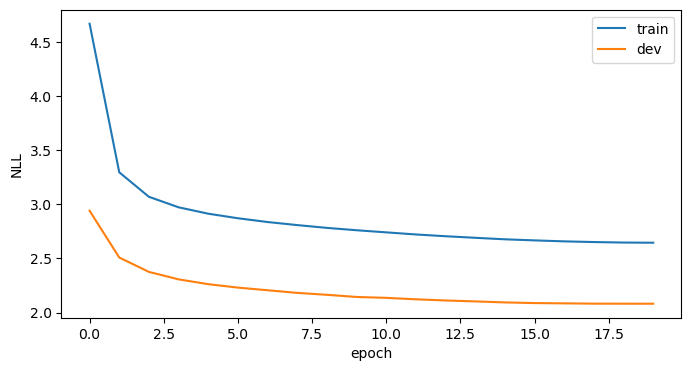

In [12]:
%pip install matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
if any(x is not None for x in dev_losses):
    plt.plot(dev_losses, label='dev')
plt.xlabel('epoch')
plt.ylabel('NLL')
plt.legend()
plt.show()


In [13]:
%pip install bert_score


Note: you may need to restart the kernel to use updated packages.


In [14]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from bert_score import score

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
    nltk.download('omw-1.4')


def compute_metrics(ref, hyp):
    ref_tokens = tokenize_text(ref)
    hyp_tokens = tokenize_text(hyp)
    smoothie = SmoothingFunction().method4
    bleu4 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    meteor = meteor_score([ref_tokens], hyp_tokens)
    return bleu4, meteor


def repetition_rate(text, n=3):
    tokens = tokenize_text(text)
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    if not ngrams:
        return 0.0
    return 1.0 - (len(set(ngrams)) / len(ngrams))


def ingredient_coverage(ingredients, generated):
    ingredient_tokens = set(tokenize_text(ingredients))
    generated_tokens = set(tokenize_text(generated))
    stop_tokens = {',', '.', 'and', 'or', '(', ')', 'c.', 'tbsp.', 'tsp.', 'oz.', 'lb.', 'pkg.', 'can'}
    ingredient_tokens = {tok for tok in ingredient_tokens if tok not in stop_tokens and not tok.replace('/', '').replace('.', '').isdigit()}
    if not ingredient_tokens:
        return 0.0
    return len(ingredient_tokens & generated_tokens) / len(ingredient_tokens)


def evaluate_on_dataset(model, data_pairs, max_items=None, output_path=None, generation_method='best_of_n'):
    # Make evaluation reproducible and explicitly checkpoint-based when possible.
    if Path(CHECKPOINT_PATH).exists():
        model, checkpoint = load_checkpoint(CHECKPOINT_PATH)
        print(f'Evaluating checkpoint epoch={checkpoint["epoch"]} dev_loss={checkpoint["best_dev_loss"]:.4f}')

    eval_pairs = data_pairs if max_items is None else data_pairs[:max_items]
    total_bleu = 0.0
    total_meteor = 0.0
    total_coverage = 0.0
    total_repetition = 0.0
    total_length = 0.0
    empty_outputs = 0
    all_preds = []
    all_golds = []
    rows = []

    for i, (ing, gold) in enumerate(eval_pairs, 1):
        pred = generate_recipe(model, ing, method=generation_method, format_steps=False)
        bleu, meteor = compute_metrics(gold, pred)
        coverage = ingredient_coverage(ing, pred)
        repetition = repetition_rate(pred)
        length = len(tokenize_text(pred))
        total_bleu += bleu
        total_meteor += meteor
        total_coverage += coverage
        total_repetition += repetition
        total_length += length
        empty_outputs += int(len(pred.strip()) == 0)
        all_preds.append(pred)
        all_golds.append(gold)
        rows.append({
            'ingredients': ing,
            'reference': gold,
            'prediction': pred,
            'generation_method': generation_method,
            'bleu4': bleu,
            'meteor': meteor,
            'ingredient_coverage': coverage,
            'repetition_rate': repetition,
            'generated_length': length,
        })
        if i % 100 == 0:
            print(f'evaluated {i}/{len(eval_pairs)}')

    mean_bleu = total_bleu / max(1, len(eval_pairs))
    mean_meteor = total_meteor / max(1, len(eval_pairs))
    P, R, F1 = score(all_preds, all_golds, lang='en', verbose=False)
    mean_bert = F1.mean().item()
    metrics = {
        'run_name': RUN_NAME,
        'checkpoint_path': CHECKPOINT_PATH,
        'generation_method': generation_method,
        'max_items': max_items,
        'num_items': len(eval_pairs),
        'bleu4': mean_bleu,
        'meteor': mean_meteor,
        'bertscore_f1': mean_bert,
        'ingredient_coverage': total_coverage / max(1, len(eval_pairs)),
        'repetition_rate': total_repetition / max(1, len(eval_pairs)),
        'average_generated_length': total_length / max(1, len(eval_pairs)),
        'empty_output_rate': empty_outputs / max(1, len(eval_pairs)),
    }
    print(f'Average BLEU-4: {mean_bleu:.4f}')
    print(f'Average METEOR: {mean_meteor:.4f}')
    print(f'Average BERTScore F1: {mean_bert:.4f}')
    print(f'Average ingredient coverage: {metrics["ingredient_coverage"]:.4f}')
    print(f'Average repetition rate: {metrics["repetition_rate"]:.4f}')

    if output_path is None:
        output_path = TRAINING_RUN_DIR / f'test_metrics_{generation_method}.json'
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump({'metrics': metrics, 'examples': rows[:100]}, f, indent=2)
    print('Metrics saved at:', output_path)
    return metrics, rows


# Full BERTScore can be slow. Start with a subset, then run full test when ready.
test_metrics, test_eval_rows = evaluate_on_dataset(model, test_pairs, max_items=500, generation_method='best_of_n')

f:\Anaconda\envs\TorchModel\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tarami\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Tarami\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
C:\Users\Tarami\AppData\Local\Temp\ipykernel_11880\6165891.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, th

Evaluating checkpoint epoch=20 dev_loss=2.0823
evaluated 100/500
evaluated 200/500
evaluated 300/500
evaluated 400/500
evaluated 500/500


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4375.01it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Average BLEU-4: 0.0823
Average METEOR: 0.3109
Average BERTScore F1: 0.8810
Average ingredient coverage: 0.4865
Average repetition rate: 0.0060
Metrics saved at: g:\FIT5120\FIT5120-ClimateQuest\AI Development\training_runs\transformer_copy_v2\test_metrics_best_of_n.json


In [15]:
def export_predictions(model, pairs, output_path=None, generation_method='best_of_n'):
    if Path(CHECKPOINT_PATH).exists():
        model, checkpoint = load_checkpoint(CHECKPOINT_PATH)
        print(f'Exporting predictions from checkpoint epoch={checkpoint["epoch"]} dev_loss={checkpoint["best_dev_loss"]:.4f}')
    if output_path is None:
        output_path = TRAINING_RUN_DIR / f'test_with_preds_transformer_copy_{generation_method}.tsv'
    with open(output_path, 'w', encoding='utf-8', newline='') as f:
        writer = csv.writer(f, delimiter='\t')
        writer.writerow(['Ingredients', 'ReferenceRecipe', 'GenerationMethod', 'GeneratedRecipe'])
        for ing, gold in pairs:
            writer.writerow([ing, gold, generation_method, generate_recipe(model, ing, method=generation_method, format_steps=False)])
    print('Done. Output saved at:', output_path)


export_predictions(model, test_pairs, generation_method='best_of_n')

Exporting predictions from checkpoint epoch=20 dev_loss=2.0823


C:\Users\Tarami\AppData\Local\Temp\ipykernel_11880\6165891.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=map_location)


Done. Output saved at: g:\FIT5120\FIT5120-ClimateQuest\AI Development\training_runs\transformer_copy_v2\test_with_preds_transformer_copy_best_of_n.tsv
